In [28]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F
import os
import matplotlib.pyplot as plt
import numpy as np

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [29]:
# Dataset and model paths
DATA_PATH = r"C:\Users\lenovo LOQ\PFA2\Sorted"  # test dataset root
MODEL_PATH = r"C:\Users\lenovo LOQ\PFA2\malware_classifier.pth"

# Batch size and FGSM epsilon
TEST_BATCH_SIZE = 32


In [30]:
# Load TorchScript model
model = torch.jit.load(MODEL_PATH, map_location=device)
model.eval()
model.to(device)


RecursiveScriptModule(
  original_name=MalwareClassifier
  (resnet): RecursiveScriptModule(
    original_name=ResNet
    (conv1): RecursiveScriptModule(original_name=Conv2d)
    (bn1): RecursiveScriptModule(original_name=BatchNorm2d)
    (relu): RecursiveScriptModule(original_name=ReLU)
    (maxpool): RecursiveScriptModule(original_name=MaxPool2d)
    (layer1): RecursiveScriptModule(
      original_name=Sequential
      (0): RecursiveScriptModule(
        original_name=Bottleneck
        (conv1): RecursiveScriptModule(original_name=Conv2d)
        (bn1): RecursiveScriptModule(original_name=BatchNorm2d)
        (conv2): RecursiveScriptModule(original_name=Conv2d)
        (bn2): RecursiveScriptModule(original_name=BatchNorm2d)
        (conv3): RecursiveScriptModule(original_name=Conv2d)
        (bn3): RecursiveScriptModule(original_name=BatchNorm2d)
        (relu): RecursiveScriptModule(original_name=ReLU)
        (downsample): RecursiveScriptModule(
          original_name=Sequential
  

In [42]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ---------------------------
# Iterative FGSM for TorchScript model
# ---------------------------
def iterative_fgsm(model, images, labels, epsilon, num_iter, alpha=None, targeted=False, random_start=True):
    """
    Iterative FGSM attack for TorchScript model with normalized inputs.
    
    Args:
        model: TorchScript or nn.Module model in eval mode
        images: [B,C,H,W] normalized tensor
        labels: ground-truth (or target) labels
        epsilon: L-inf budget (in normalized space)
        num_iter: number of iterations
        alpha: step size per iteration
        targeted: if True, targeted attack
        random_start: if True, initialize in epsilon ball
    
    Returns:
        x_adv: adversarial examples [B,C,H,W]
    """
    # ImageNet normalization min/max
    norm_mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(1,3,1,1)
    norm_std  = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(1,3,1,1)
    norm_min = (0.0 - norm_mean) / norm_std
    norm_max = (1.0 - norm_mean) / norm_std

    if alpha is None:
        alpha = epsilon / max(num_iter, 1)
    
    # Start from original image or random perturbation
    if random_start:
        delta = torch.empty_like(images).uniform_(-epsilon, epsilon)
        x_adv = torch.clamp(images + delta, norm_min, norm_max)
    else:
        x_adv = images.clone()

    for _ in range(num_iter):
        x_adv.requires_grad = True
        outputs = model(x_adv)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()

        step = alpha * x_adv.grad.sign()
        if targeted:
            step = -step

        x_adv = x_adv + step
        # Project back to epsilon ball
        x_adv = torch.clamp(images + (x_adv - images).clamp(-epsilon, epsilon), norm_min, norm_max).detach()

    return x_adv

# ---------------------------
# Visualization of a single image
# ---------------------------
def visualize_ifgsm(model, image, label, epsilon=0.01, num_iter=10, targeted=False, target_class=None, class_names=None):
    """
    Visualize I-FGSM adversarial attack on a single image.
    """
    image = image.unsqueeze(0)  # add batch dimension
    label = label.unsqueeze(0)

    def _make_adv(m, xb, yb):
        y_used = yb if not targeted else torch.full_like(yb, target_class)
        return iterative_fgsm(m, xb, y_used, epsilon, num_iter, alpha=epsilon/num_iter, targeted=targeted, random_start=True)

    # Generate adversarial
    adv_image = _make_adv(model, image, label).squeeze(0)

    # Get predictions
    with torch.no_grad():
        orig_pred = model(image).argmax(dim=1).item()
        adv_pred  = model(adv_image.unsqueeze(0)).argmax(dim=1).item()

    # Denormalize for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(image.device)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(image.device)
    image_disp = torch.clamp(image.squeeze(0)*std + mean, 0, 1)
    adv_disp   = torch.clamp(adv_image*std + mean, 0, 1)

    # Plot
    fig, axes = plt.subplots(1,2, figsize=(8,4))
    axes[0].imshow(image_disp.permute(1,2,0).cpu())
    axes[0].set_title(f"Original: {class_names[orig_pred] if class_names else orig_pred}")
    axes[0].axis('off')

    axes[1].imshow(adv_disp.permute(1,2,0).cpu())
    axes[1].set_title(f"Adversarial: {class_names[adv_pred] if class_names else adv_pred}")
    axes[1].axis('off')

    plt.suptitle(f"I-FGSM Attack (epsilon={epsilon})")
    plt.show()


In [32]:
# Get a batch of test images
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# Attack parameters
epsilon = 0.8      # max perturbation in normalized space
num_iter = 10      # number of I-FGSM iterations
alpha = epsilon / num_iter  # step size per iteration

# -----------------------------
# 1) Compute clean predictions
# -----------------------------
with torch.no_grad():
    clean_pred = model(images).argmax(dim=1)

# -----------------------------
# 2) Generate adversarial examples
# -----------------------------
x_adv_ifgsm = iterative_fgsm(
    model, images, labels,
    epsilon=epsilon,
    num_iter=num_iter,
    alpha=alpha,
    targeted=False,
    random_start=True
)

# -----------------------------
# 3) Compute adversarial predictions
# -----------------------------
with torch.no_grad():
    adv_pred_ifgsm = model(x_adv_ifgsm).argmax(dim=1)

# -----------------------------
# 4) Measure how many original correct predictions were flipped
# -----------------------------
originally_correct = clean_pred == labels
flipped_ifgsm = (adv_pred_ifgsm != labels) & originally_correct

flip_percentage = (flipped_ifgsm.float().sum() / originally_correct.float().sum().clamp_min(1.0)).item()

print(f"I-FGSM flips (first batch): {flip_percentage:.2%}")


I-FGSM flips (first batch): 100.00%


In [33]:
import torch
import torch.nn.functional as F

def iterative_fgsm(model, images, labels, epsilon, num_iter, alpha=None, targeted=False, random_start=True):
    if alpha is None:
        alpha = epsilon / max(num_iter, 1)
    x_adv = images.clone()
    if random_start:
        delta = torch.empty_like(images).uniform_(-epsilon, epsilon)
        x_adv = torch.clamp(images + delta, 0, 1)

    for _ in range(num_iter):
        x_adv.requires_grad = True
        outputs = model(x_adv)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        step = alpha * x_adv.grad.sign()
        if targeted:
            step = -step
        x_adv = x_adv + step
        x_adv = torch.clamp(images + (x_adv - images).clamp(-epsilon, epsilon), 0, 1).detach()

    return x_adv

In [41]:
adv_image = iterative_fgsm(model, image.unsqueeze(0), label.unsqueeze(0),
                           epsilon=0.0, num_iter=10, targeted=False)
adv_pred = model(adv_image).argmax(dim=1).item()
print("Prediction with epsilon=0:", adv_pred)


Prediction with epsilon=0: 2


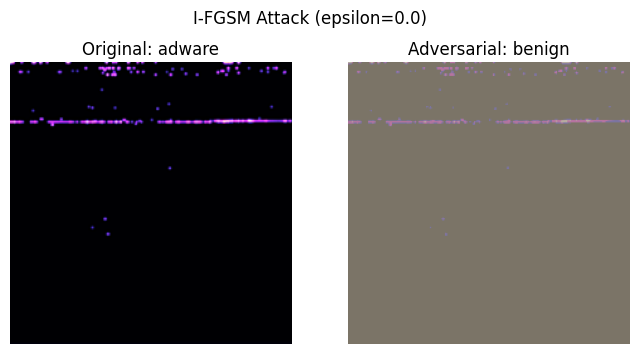

In [40]:
import matplotlib.pyplot as plt
import torch

# Make sure model is on device and in eval mode
model.eval()
device = next(model.parameters()).device

# Pick one batch from test_loader
images, labels = next(iter(test_loader))
image = images[0].to(device)
label = labels[0].to(device)

# Attack parameters
epsilon = 0.0000
num_iter = 10
alpha = epsilon / num_iter

# Generate adversarial example
adv_image = iterative_fgsm(
    model, image.unsqueeze(0), label.unsqueeze(0),
    epsilon=epsilon,
    num_iter=num_iter,
    alpha=alpha,
    targeted=False,
    random_start=True
).squeeze(0)

# Get predictions
with torch.no_grad():
    orig_pred = model(image.unsqueeze(0)).argmax(dim=1).item()
    adv_pred  = model(adv_image.unsqueeze(0)).argmax(dim=1).item()

# Optional: class names
class_names = train_loader.dataset.classes  # ['adware', 'ransomware', 'trojan']

# Denormalize (if using ImageNet normalization)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(device)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(device)
image_disp = torch.clamp(image * std + mean, 0, 1)
adv_disp   = torch.clamp(adv_image * std + mean, 0, 1)

# Display original and adversarial
fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(image_disp.permute(1,2,0).cpu())
axes[0].set_title(f"Original: {class_names[orig_pred]}")
axes[0].axis('off')

axes[1].imshow(adv_disp.permute(1,2,0).cpu())
axes[1].set_title(f"Adversarial: {class_names[adv_pred]}")
axes[1].axis('off')

plt.suptitle(f"I-FGSM Attack (epsilon={epsilon})")
plt.show()


In [34]:
import torch
from torch import nn, Tensor
import matplotlib.pyplot as plt

# Make sure iterative_fgsm is already adapted for ImageNet normalization
# and that your model is your MalwareClassifier

def visualize_ifgsm(model: nn.Module,
                    image: Tensor,
                    label: Tensor,
                    epsilon: float,
                    num_iter: int,
                    targeted: bool = False,
                    target_class: int | None = None,
                    class_names: list[str] | None = None) -> None:
    """
    Visualize I-FGSM attack on a single image for MalwareClassifier.

    Args:
        model: Your trained MalwareClassifier
        image: Single image tensor [C,H,W], normalized
        label: True label (scalar tensor)
        epsilon: Max perturbation (normalized space)
        num_iter: Number of I-FGSM iterations
        targeted: If True, perform a targeted attack
        target_class: Target class index if targeted
        class_names: Optional list of class names for display
    """
    alpha = epsilon / max(num_iter, 1)
    
    def _make_adv(m, xb, yb):
        y_used = yb if not targeted else torch.full_like(yb, target_class)
        return iterative_fgsm(
            m, xb.unsqueeze(0), y_used.unsqueeze(0),
            epsilon=epsilon,
            num_iter=num_iter,
            alpha=alpha,
            targeted=targeted,
            random_start=True
        ).squeeze(0)
    
    # Generate adversarial example
    model.eval()
    adv_image = _make_adv(model, image.to(next(model.parameters()).device), label.to(next(model.parameters()).device))
    
    # Get predictions
    with torch.no_grad():
        orig_pred = model(image.unsqueeze(0).to(next(model.parameters()).device)).argmax(dim=1).item()
        adv_pred = model(adv_image.unsqueeze(0).to(next(model.parameters()).device)).argmax(dim=1).item()
    
    # Denormalize for display (ImageNet stats)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    image_disp = image.cpu() * std + mean
    adv_disp = adv_image.cpu() * std + mean

    # Clip to [0,1]
    image_disp = torch.clamp(image_disp, 0, 1)
    adv_disp = torch.clamp(adv_disp, 0, 1)
    
    # Display
    fig, axes = plt.subplots(1, 2, figsize=(8,4))
    axes[0].imshow(image_disp.permute(1,2,0))
    axes[0].set_title(f"Original: {class_names[orig_pred] if class_names else orig_pred}")
    axes[0].axis('off')
    
    axes[1].imshow(adv_disp.permute(1,2,0))
    axes[1].set_title(f"Adversarial: {class_names[adv_pred] if class_names else adv_pred}")
    axes[1].axis('off')
    
    plt.suptitle(f"I-FGSM {'Targeted' if targeted else 'Untargeted'} Attack")
    plt.show()
